In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import os

os.chdir("../")
from scripts import utils, alerceanomalies
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.svm import OneClassSVM
import distclassipy as dcpy
from distclassipy.anomaly import DistanceAnomaly

from sklearn.base import BaseEstimator, OutlierMixin
epsilon = np.finfo(np.float32).eps
with open("settings.txt") as f:
    settings_dict = json.load(f)
seed_val = settings_dict["seed_choice"]
np.random.seed(seed_val)
sns_dict = settings_dict["sns_dict"]
sns.set_theme(**sns_dict)

from IPython.core.display import HTML
from IPython.display import display

import squarify
set3colors = [matplotlib.colors.rgb2hex(x) for x in plt.cm.Set3.colors]
knowncolors = set3colors[:4]
unknowncolors = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#a9a9a9']
unknowncolors = set3colors[4:]+unknowncolors

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [2]:
# Create a dictionary of all models to test
models_to_test = {
    "DistClassiPy (min-median)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='median',
        normalize_scores=True
    ),
    
    "DistClassiPy (min-mean)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='mean',
        normalize_scores=True
    ),

    "IsolationForest": IsolationForest( #using alerce anomaly params
        n_estimators=100,
        max_samples=256,
        contamination=0.001,
        random_state=seed_val+2
    ),
    "LocalOutlierFactor": LocalOutlierFactor(
        n_neighbors=20, 
        novelty=True,  # IMPORTANT: Allows use on new data
        contamination='auto'
    ),
    
    "OneClassSVM": OneClassSVM(
        kernel='rbf',
        nu=0.001
    ),

    "Autoencoder": alerceanomalies.AutoencoderAnomalyDetector(
        encoding_dim=32, # Can be tuned
        epochs=200,
        patience=10,
    ),


    "Variational Autoencoder": alerceanomalies.VAEAnomalyDetector(
        encoding_dim=32, # Can be tuned
        epochs=200,
        patience=10,
        loss_samples=5 # Number of samples for the reconstruction term in ELBO
    ),

    "DeepSVDD": alerceanomalies.DeepSVDDAnomalyDetector(
        encoding_dim=32, # Can be tuned
        epochs=200,
        patience=10,
    ),

    "ClassSVDD": alerceanomalies.ClassSVDDAnomalyDetector(
        z_dim=64,
        epochs=250,
        patience=15,
        lr=1e-4,
        verbose=False
    )
}

In [3]:
traindat = pd.read_pickle("data/alercedata/train_data_filtered.pkl").set_index("oid")
testdat = pd.read_pickle("data/alercedata/test_data_filtered.pkl").set_index("oid")
feature_list = pd.read_pickle("data/alercedata/features_BHRF_model.pkl")

commondat = pd.concat([traindat,testdat])
commondat=commondat.rename(columns={"classALeRCE":"class"})

#### RESAMPLE
# commondat=commondat.groupby('class').apply(lambda x: x.sample(n=min(3000,len(x)), random_state=seed_val)).reset_index(drop=True) 

In [9]:
def run_anom_exp(fulldata, new_knowns, new_unknowns,final_features):
    y_knowns_df = knowns["class"]
    X_knowns_df = knowns.loc[:, final_features]
    
    X_anom_df = unknowns.loc[:, X_knowns_df.columns].dropna()
    X_anom_df = X_anom_df.drop(np.intersect1d(X_anom_df.index, X_knowns_df.index))
    y_anom_df = unknowns.loc[X_anom_df.index]["class"]
    X_anom_df=X_anom_df.loc[y_anom_df.index]
    X_all_df = pd.concat([X_knowns_df, X_anom_df]).sample(frac=1)
    y_all_df = pd.concat([y_knowns_df, y_anom_df]).loc[X_all_df.index]

    # shift knowns/unknowns classes
    if new_knowns is not None or new_unknowns is not None:
        new_unknown_idx = y_all_df.isin(new_unknowns)
        new_known_idx = y_all_df.isin(new_knowns)
        del(X_knowns_df, X_anom_df)
        
        X_knowns_df = X_all_df.loc[new_known_idx]
        y_knowns_df = y_all_df.loc[new_known_idx]
        X_anom_df = X_all_df.loc[new_unknown_idx]
        y_anom_df = y_all_df.loc[new_unknown_idx]
        
        del(X_all_df)
        
        X_all_df = pd.concat([X_knowns_df, X_anom_df]).sample(frac=1)
        y_all_df = pd.concat([y_knowns_df, y_anom_df]).loc[X_all_df.index]


    results_df = pd.DataFrame(index=X_all_df.index)
    results_df['class'] = y_all_df
    known_classes = set(y_knowns_df.unique())
    mask = results_df['class'].isin(known_classes)
    results_df['status'] = np.where(mask, 'normal', 'anomalous')

    # Loop through models, fit, score, and store results
    for model_name, model in tqdm(models_to_test.items(), desc="Running Models"):
        # print(f"--- Training {model_name} ---")
        
        # Fit the model on the NORMAL data only
        if model_name in ["IsolationForest", "LocalOutlierFactor", "OneClassSVM"]:
            model.fit(X_knowns_df.to_numpy())
        else:
            model.fit(X_knowns_df.to_numpy(), y_knowns_df.to_numpy())
        
        # Get anomaly scores for ALL data
        # Note: IF and LOF score lower for anomalies, so we negate them.
        # Your method and AE score higher for anomalies, so no change is needed.
        scores = model.decision_function(X_all_df.to_numpy())
        
        if model_name in ["IsolationForest", "LocalOutlierFactor", "OneClassSVM"]:
            scores = -scores # Lower is more anomalous for these, so we flip
            
        results_df[f'score_{model_name}'] = scores

    # pass

    topn = 100
    print(f"How many anomalies in top {topn} preds?")
    for col in results_df.columns[2:]:
        print("*"*10, col, "*"*10)
        display(results_df.sort_values(by=[col],ascending=False)["status"].iloc[:topn].value_counts())



    anomcounts = y_anom_df.value_counts()
    knowncounts = y_knowns_df.value_counts()
    anomcounts.index = [x[:14] for x in anomcounts.index]
    
    # Utility function to build a labeled list
    def format_labels(series):
        return [f"{cls}\n({count})" for cls, count in zip(series.index, series.values)]
    
    
    squarify.plot(
        sizes=anomcounts.values,
        label=format_labels(anomcounts),
        color=sns.color_palette(unknowncolors),
        alpha=0.8,
        text_kwargs={'fontsize':6}
    )
    plt.gca().axis('off')
    plt.title(f'{anomcounts.sum()} Unseen Objects in {len(anomcounts)} Classes',fontsize=14)
    # plt.savefig("unknown.png", dpi=300, bbox_inches="tight")
    plt.show()

    squarify.plot(
        sizes=knowncounts.values,
        label=format_labels(knowncounts),
        color=sns.color_palette(knowncolors),
        alpha=0.8,
        text_kwargs={'fontsize':14}
    )
    plt.gca().axis('off')
    plt.title(f'{knowncounts.sum()} Seen Objects in {len(knowncounts)} Classes',fontsize=14)
    plt.show()

    print("Total anoms:")
    print(results_df["status"].value_counts())
    max_anom = results_df["status"].value_counts()["anomalous"]

    top_n = min(200, max_anom)
    
    print("*"*10, f"Check top {top_n} candidates for each model", "*"*10)
    # Example: Check top 200 candidates for each model
    
    for model_name in models_to_test.keys():
        score_col = f'score_{model_name}'
        print(f"\n--- Top {top_n} candidates for {model_name} ---")
        
        top_candidates = results_df.sort_values(score_col, ascending=False).head(top_n)
        display(top_candidates['status'].value_counts(normalize=True))


    methods_percent = {}
    
    # baseline = []
    
    for model_name in tqdm(models_to_test.keys(),desc="method"):
        methods_percent[model_name] = []
        score_col = f'score_{model_name}'
        # normalize=True
        for top_n in tqdm(range(1, min(max_anom,500)), desc="topn",leave=False):
            top_candidates = results_df.sort_values(score_col, ascending=False).head(top_n)
            valcounts = top_candidates['status'].value_counts(normalize=True,ascending=True)
            # valcounts = top_candidates['status'].value_counts(normalize=False,ascending=True)
    
            if "anomalous" in valcounts.index:
                frac = valcounts["anomalous"]
                # frac = valcounts["anomalous"] / len(y_anom_df)
            else:
                frac = 0
            methods_percent[model_name].append(frac)


    endnum = min(200, max_anom-1)
    # endum = len(results_df)+1
    
    top_ns = np.arange(start=1, stop=endnum+1)
    
    
    for model_name in models_to_test.keys():
        plt.plot(top_ns, methods_percent[model_name][:endnum], label=model_name, linewidth=2)
    plt.ylabel("Purity", fontsize=16)
    plt.xlabel("Follow-up Budget (No. of sources)", fontsize=16)
    plt.gca().tick_params(axis='both', which='major', labelsize=16)
    plt.gca().tick_params(axis='both', which='minor', labelsize=12)
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
    # plt.savefig(f"top{endnum}budget4methods.png",dpi=300,bbox_inches="tight")
    plt.show()


    endum = len(results_df)
    
    top_ns = np.arange(start=1, stop=endnum+1)
    
    
    for model_name in models_to_test.keys():
        plt.plot(top_ns, methods_percent[model_name][:endnum], label=model_name)
    plt.ylabel("Purity", fontsize=16)
    plt.xlabel("Follow-up Budget (No. of sources)", fontsize=16)
    plt.gca().tick_params(axis='both', which='major', labelsize=16)
    plt.gca().tick_params(axis='both', which='minor', labelsize=12)
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
    # plt.savefig("allobjsbudget4methods.png",dpi=300,bbox_inches="tight")
    plt.show()

    # ranks = results_df.iloc[:, 2:].rank(ascending=False, method='dense')
    # ranks.loc[results_df[results_df["class"] == "KN_B19"].index].sum()
    
    n = min(100, max_anom)
    
    all_models = list(models_to_test.keys())
    
    print(f"Comparing top {n} {all_models[0]} with")
    for model_name in all_models[1:]:
        print("*"*3+model_name)
        common = len(np.intersect1d(results_df.sort_values(
            by="score_DistClassiPy (min-median)",
            ascending=False).iloc[:n].index, 
                                    results_df.sort_values(
                                        by=f"score_{model_name}",ascending=False).iloc[:n].index))
        
        print(f"\tCommon = {common}")
        print(f"\tCommon % = {(common/n):.1%}")
    
    # how many of the top 100 of dcpy are shared with the union (aka combined) top 100 for ALL OTHERS
    
    all_models = list(models_to_test.keys())
    
    othercommon_idxs = []
    for model_name in all_models[1:]:
        if "distclassipy" in model_name.lower():
            continue
        cur = results_df.sort_values(
            by=f"score_{model_name}",ascending=False).iloc[:n].index
        othercommon_idxs = np.union1d(othercommon_idxs, cur)
    
    topdcpy = results_df.sort_values(by=f"score_{all_models[0]}",ascending=False).iloc[:n]
    
    common = np.intersect1d(othercommon_idxs, topdcpy.index)
    common_len = len(common)
    print(f"{all_models[0]} common with top {n} for ALL OTHER: {common_len} ({(common_len/n):.1%})")
    
    print(topdcpy.loc[~topdcpy.index.isin(common)]["status"].value_counts())
    print(topdcpy.loc[~topdcpy.index.isin(common)]["status"].value_counts(normalize=True))
    #which of the unique dcpy ones are actually anomalous?
    
    # 
    # for j in range(len(all_models)):
    #     for model_name in all_models[1+j:]:
    #         print(f"{all_models[j]} - {model_name}")
    #         common = len(np.intersect1d(results_df.sort_values(
    #             by="score_DistClassiPy (min-median)",
    #             ascending=False).iloc[:n].index, 
    #                                     results_df.sort_values(
    #                                         by=f"score_{model_name}",ascending=False).iloc[:n].index))
            
    #         print(f"\tCommon = {common}")
    #         print(f"\tCommon % = {(common/n):.1%}")
    
    
    for col in results_df.columns[2:]:
        print(col)
        display(HTML(results_df.sort_values(by=col,ascending=False)[["class", "status"]].iloc[:20].to_html()))
    
    
    # snid = 141445943
    # lcdf = pd.read_parquet("data/otherclassobjs.parquet")
    # # lcdf = pd.read_parquet("data/Cepheid.parquet")
    # try:
    #     lcdf=lcdf.set_index("SNID")
    # except Exception:
    #     pass
    # def plot_lc(lcdf, snid):
    #     chosen_df = lcdf.loc[snid]
    #     cols = ["MJD", "FLUXCAL", "FLUXCALERR", "BAND", "PHOTFLAG", "ZEROPT"]
    #     dat = []
    #     for col in cols:
    #         if col in cols:
    #             dat.append(chosen_df.loc[col])
    #     dat = np.array(dat).T
    #     lc = pd.DataFrame(data=dat,columns=cols).sort_values(by="MJD")
    
    #     plt.figure(figsize=(4, 4))
    #     for band in "ugrizY":
    #         lc_band = lc[lc["BAND"] == band]
    #         plt.errorbar(
    #             x=lc_band["MJD"],
    #             y=lc_band["FLUXCAL"],
    #             yerr=lc_band["FLUXCALERR"],
    #             fmt="o",
    #             label=f"{band}",
    #         )
    #     plt.xlabel("Time (in days)")
    #     plt.ylabel("Brightness (flux)")
    #     ax = plt.gca()
    #     x = ax.get_xticks()
    #     ax.set_xticks(x[1:-1:1])
    #     ax.tick_params(axis="both", which="major")
    #     ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    #     # ax.legend(bbox_to_anchor=(1.14, 0.55),ncol=1,loc="lower center")
    #     # plt.title(f"OID {objid} ({cur_cl})")
    #     # plt.xlim(peak_mjd - 40, peak_mjd + 90)
    #     # plt.grid()
    #     plt.savefig("lc.png", bbox_inches="tight", dpi=300)
    #     plt.show()
    # plot_lc(lcdf,snid)

Running Models:   0%|          | 0/5 [00:00<?, ?it/s]

How many anomalies in top 100 preds?
********** score_DistClassiPy (min-median) **********


status
anomalous    57
normal       43
Name: count, dtype: int64

********** score_DistClassiPy (min-mean) **********


status
anomalous    75
normal       25
Name: count, dtype: int64

...

status
anomalous    61
normal       39
Name: count, dtype: int64

********** score_LocalOutlierFactor **********


status
anomalous    84
normal       16
Name: count, dtype: int64

********** score_OneClassSVM **********


status
anomalous    87
normal       13
Name: count, dtype: int64

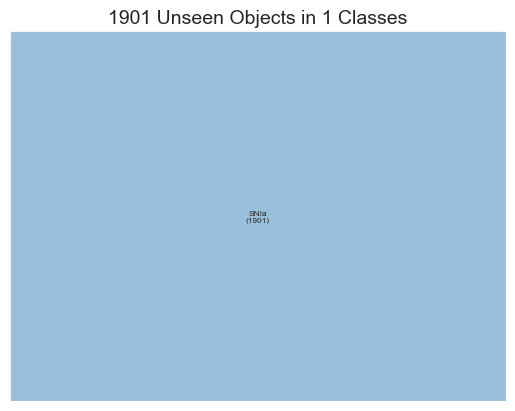

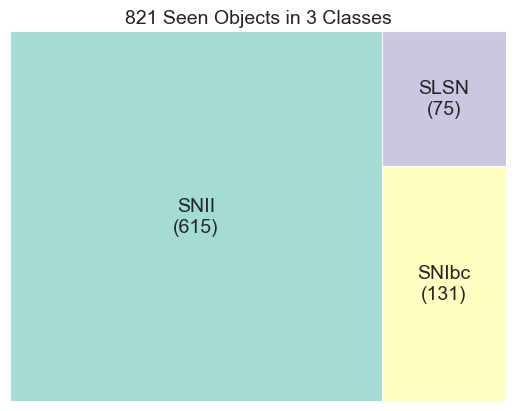

Total anoms:
status
anomalous    1901
normal        821
Name: count, dtype: int64
********** Check top 200 candidates for each model **********

--- Top 200 candidates for DistClassiPy (min-median) ---


status
anomalous    0.62
normal       0.38
Name: proportion, dtype: float64


--- Top 200 candidates for DistClassiPy (min-mean) ---


status
anomalous    0.76
normal       0.24
Name: proportion, dtype: float64


--- Top 200 candidates for IsolationForest ---


...

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

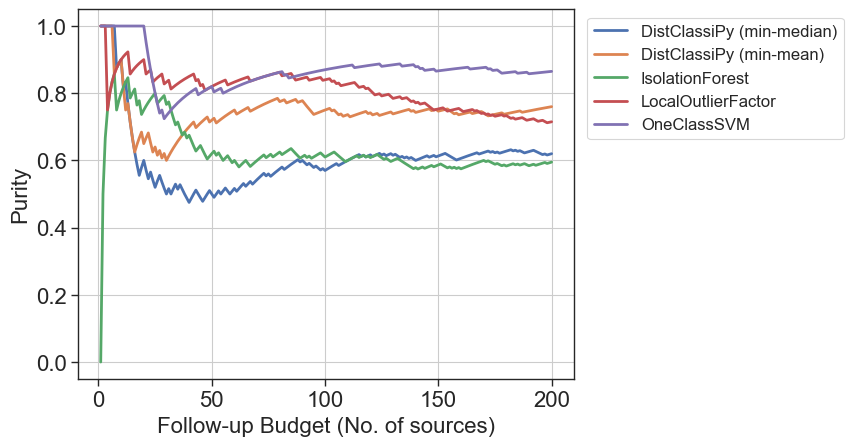

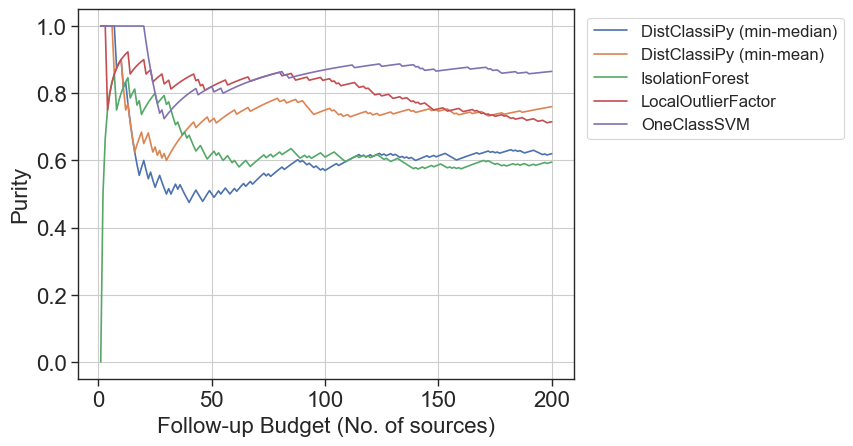

Comparing top 100 DistClassiPy (min-median) with
***DistClassiPy (min-mean)
	Common = 75
	Common % = 75.0%
***IsolationForest
	Common = 46
	Common % = 46.0%
***LocalOutlierFactor
	Common = 24
	Common % = 24.0%
***OneClassSVM
	Common = 23
	Common % = 23.0%
DistClassiPy (min-median) common with top 100 for ALL OTHER: 54 (54.0%)
status
anomalous    32
normal       14
Name: count, dtype: int64
status
anomalous    0.695652
normal       0.304348
Name: proportion, dtype: float64
score_DistClassiPy (min-median)


,class,status
oid,,
ZTF20abijfqq,SNIa,anomalous
ZTF21aaabvit,SNIa,anomalous
ZTF20aavpnlv,SNIa,anomalous
ZTF21aaqytjr,SNIa,anomalous
ZTF19aacgslb,SNIa,anomalous
ZTF20achlced,SNIa,anomalous
ZTF21aaprfqv,SNIa,anomalous
ZTF20aaelulu,SNIbc,normal
ZTF20aaumsrr,SNIa,anomalous


score_DistClassiPy (min-mean)


,class,status
oid,,
ZTF20abijfqq,SNIa,anomalous
ZTF20aavpnlv,SNIa,anomalous
ZTF21aaabvit,SNIa,anomalous
ZTF21aaqytjr,SNIa,anomalous
ZTF20achlced,SNIa,anomalous
ZTF19aacgslb,SNIa,anomalous
ZTF20aaelulu,SNIbc,normal
ZTF21aaprfqv,SNIa,anomalous
ZTF21aarqkes,SNIa,anomalous


score_IsolationForest


,class,status
oid,,
ZTF20aaelulu,SNIbc,normal
ZTF21aaabvit,SNIa,anomalous
ZTF21aaqytjr,SNIa,anomalous
ZTF21aaprfqv,SNIa,anomalous
ZTF19aacgslb,SNIa,anomalous
ZTF20achlced,SNIa,anomalous
ZTF20abijfqq,SNIa,anomalous
ZTF18acbwaxk,SNII,normal
ZTF21aarqkes,SNIa,anomalous


score_LocalOutlierFactor


,class,status
oid,,
ZTF21aaqytjr,SNIa,anomalous
ZTF21aaabvit,SNIa,anomalous
ZTF20abijfqq,SNIa,anomalous
ZTF20aaelulu,SNIbc,normal
ZTF19aacgslb,SNIa,anomalous
ZTF21aaprfqv,SNIa,anomalous
ZTF20achlced,SNIa,anomalous
ZTF20aaumsrr,SNIa,anomalous
ZTF21aarqkes,SNIa,anomalous


score_OneClassSVM


,class,status
oid,,
ZTF19aacgslb,SNIa,anomalous
ZTF20achlced,SNIa,anomalous
ZTF21aaabvit,SNIa,anomalous
ZTF20aaumsrr,SNIa,anomalous
ZTF21aaqytjr,SNIa,anomalous
ZTF21aaprfqv,SNIa,anomalous
ZTF20aavpnlv,SNIa,anomalous
ZTF20abijfqq,SNIa,anomalous
ZTF21aarqkes,SNIa,anomalous


In [15]:
myknowns = ["SNII", "SNIbc", "SLSN"]

myunknowns = ["SNIa"]


myfeatures = [
"SPM_A_1",
"SPM_t0_1",
"SPM_gamma_1",
"SPM_beta_1",
"SPM_tau_rise_1",
"SPM_tau_fall_1",
"SPM_chi_1",
"SPM_A_2",
"SPM_t0_2",
"SPM_gamma_2",
"SPM_beta_2",
"SPM_tau_rise_2",
"SPM_tau_fall_2",
"SPM_chi_2",
]

knowns=knowns.loc[knowns[myfeatures].dropna().index]
unknowns=unknowns.loc[unknowns[myfeatures].dropna().index]

run_anom_exp(new_knowns=myknowns, new_unknowns=myunknowns,final_features=myfeatures)